<div style="font-family: 'Segoe UI', Arial, sans-serif; 
            border-left: 5px solid #1f77b4; 
            padding: 20px; 
            background-color: #f8f9fa; 
            border-radius: 4px; 
            box-shadow: 0 1px 3px rgba(0,0,0,0.05); 
            max-width: 800px; 
            margin-bottom: 25px;">
    
<h1 style="color: #212529; margin-top: 0; margin-bottom: 5px; font-size: 26px; font-weight: 700;">
    Part II: CMS Open Data
</h1>
<br>
<p style="color: #6c757d; margin-top: 0; margin-bottom: 20px; font-size: 18px; font-weight: bold;">
    Notebook 6: Event Selection and Filtering
</p>

<hr style="border: 0; border-top: 1px solid #dee2e6; margin-bottom: 15px;">

<table style="border-collapse: collapse; width: 100%; font-size: 14px; line-height: 1.6;">
    <tr>
        <td style="padding: 4px 0; width: 150px; font-weight: bold; color: #495057;">Author:</td>
        <td style="padding: 4px 0; color: #212529;">Uditangshu Roy</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Affiliation:</td>
        <td style="padding: 4px 0; color: #212529;">Undergraduate, Department of Physics and Astronomy, The University of Manchester</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Contact:</td>
        <td style="padding: 4px 0; color: #1f77b4; text-decoration: none;">roy.uditangshu@gmail.com</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Date:</td>
        <td style="padding: 4px 0; color: #212529;">August 2026</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Dataset Source:</td>
        <td style="padding: 4px 0; color: #212529;">CERN Open Data: <i> Datasets derived from the Run2011A SingleElectron, SingleMu, DoubleElectron, and DoubleMu primary datasets</i>.
            <code>Dimuon_DoubleMu.csv</code>. McCauley, T. Recorded 2011. Published 2017.</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Software Env.:</td>
        <td style="padding: 4px 0; color: #212529;">Python 3.x, Pandas, Matplotlib, NumPy, Pathlib, IPython</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">ORCID:</td>
        <td style="padding: 4px 0; color: #212529; font-family: monospace; letter-spacing: 0.5px;"><a href="https://orcid.org/0009-0005-7992-3549">0009-0005-7992-3549</a></td>
    </tr>
</table>
</div>

## 1. &nbsp; Introduction

The CMS Open Data dimuon sample contains all reconstructed dimuon events recorded under the selected trigger conditions rather than exclusively $Z$-boson decays. Consequently, the majority of events originate from alternative physical processes, detector backgrounds or poorly reconstructed tracks. Before reconstructing the invariant mass spectrum, it is therefore necessary to apply a series of physics-motivated selection criteria that suppress background contributions while retaining genuine $Z \rightarrow \mu^+\mu^-$ candidate events. This notebook develops a sequential event-selection procedure and quantifies the effect of each requirement on the dataset.

In [1]:
#Import libraries and modules

import sys
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utilities import (
    TABLE_STYLES,
    dataset_information
)

from src.plotting import (
    set_plot_style,
    plot_histogram,
    plot_bar,
    plot_line
)

from src.selection import (
    select_global_muons,
    select_opposite_charge_pairs,
    leading_subleading_pt,
    select_transverse_momentum,
    select_pseudorapidity,
    select_invariant_mass,
    selection_summary
)

set_plot_style()  # sets matplotlib rc-params

#Center-align outputs
display(HTML("""
<style>
.jp-OutputArea-output {
    display: flex;
    justify-content: center;
    align-items: center;
}
</style>
"""))

## 2. &nbsp; Physics Motivation

### 2.1 &nbsp; Why Event Selection is Required

Although every event in the dataset contains two reconstructed muons, not every dimuon pair originates from the decay of a $Z$-boson. Numerous competing processes produce muon pairs, including heavy-flavour decays, Drell–Yan production at low invariant mass [1], cosmic-ray muons and detector misreconstruction. The objective of the event-selection procedure is therefore to remove these backgrounds while preserving the characteristic properties expected for genuine $Z \rightarrow \mu^+\mu^-$ events.

### 2.2 &nbsp; Expected Characteristics of $Z \rightarrow \mu^+\mu^-$

The decay of a Z-boson into a pair of oppositely charged muons possesses several well-established experimental signatures that distinguish it from many other dimuon production processes observed at the LHC. These characteristic properties provide the physical motivation for the event-selection criteria applied throughout this analysis.

Firstly, the two reconstructed muons are expected to carry opposite electric charge, reflecting the decay process $Z \rightarrow \mu^+\mu^-$. Requiring opposite-sign muons therefore removes events that are incompatible with the expected decay topology and suppresses background arising from charge misidentification and unrelated particle combinations.

Secondly, the decay products of a $91.2 \, \text{GeV}$ [2] $Z$-boson typically possess relatively large transverse momenta. Although the exact momentum depends upon the kinematics of the parent boson, genuine $Z$-boson events generally produce significantly more energetic muons than many low-mass background processes. Applying a minimum transverse momentum requirement therefore preferentially retains signal events while rejecting a substantial fraction of low-energy backgrounds.

The quality of the reconstructed muons is also an important consideration. Within the CMS detector, Global Muons are reconstructed by combining information from both the inner silicon tracker and the outer muon chambers, resulting in improved momentum resolution and greater reconstruction reliability compared with tracker-only muons. Consequently, this analysis preferentially selects events in which both reconstructed particles are identified as Global Muons.

Finally, genuine $Z$-boson decays are expected to produce a dimuon invariant mass close to the accepted Z-boson mass of approximately $91.2 \, \text{GeV}$ [2]. While the invariant mass will ultimately be reconstructed independently in a later stage of this project, the value supplied within the CMS dataset may be used as a preliminary selection variable to reduce the large background contribution before performing the final reconstruction.

Some commonly used selection variables employed in professional CMS analyses, such as track isolation and transverse impact parameter, are not available within the <code>Dimuon_DoubleMu</code> educational dataset. Consequently, the event-selection procedure developed in this notebook is necessarily restricted to the reconstructed quantities provided by the dataset, namely the muon reconstruction type, electric charge, momentum components and invariant mass. Despite these limitations, the available observables remain sufficient to isolate a clean sample of $Z \rightarrow \mu^+\mu^-$ candidate events suitable for the subsequent invariant mass reconstruction.

### 2.3 &nbsp; Load Dataset

In [2]:
dimuon = pd.read_csv("../../data/raw/cms_full/Dimuon_DoubleMu.csv")

## 3. &nbsp; Selection Criteria

### 3.1 &nbsp; Muon Reconstruction Quality

Within the CMS detector, reconstructed muons are classified according to the detector systems used during the reconstruction process. Tracker Muons are reconstructed primarily using information from the inner silicon tracking detector, providing reliable measurements for many particles but with limited information from the dedicated muon system. In contrast, Global Muons are reconstructed by combining tracks measured in both the inner silicon tracker and the outer muon chambers through a global track fit. This combined reconstruction generally yields improved momentum resolution, more accurate track parameters and greater confidence that the particle has been correctly identified as a muon. Consequently, events containing two Global Muons are expected to provide the highest-quality measurements and are therefore selected for the subsequent stages of the analysis.

GG    93474
GT     6526
Name: count, dtype: int64

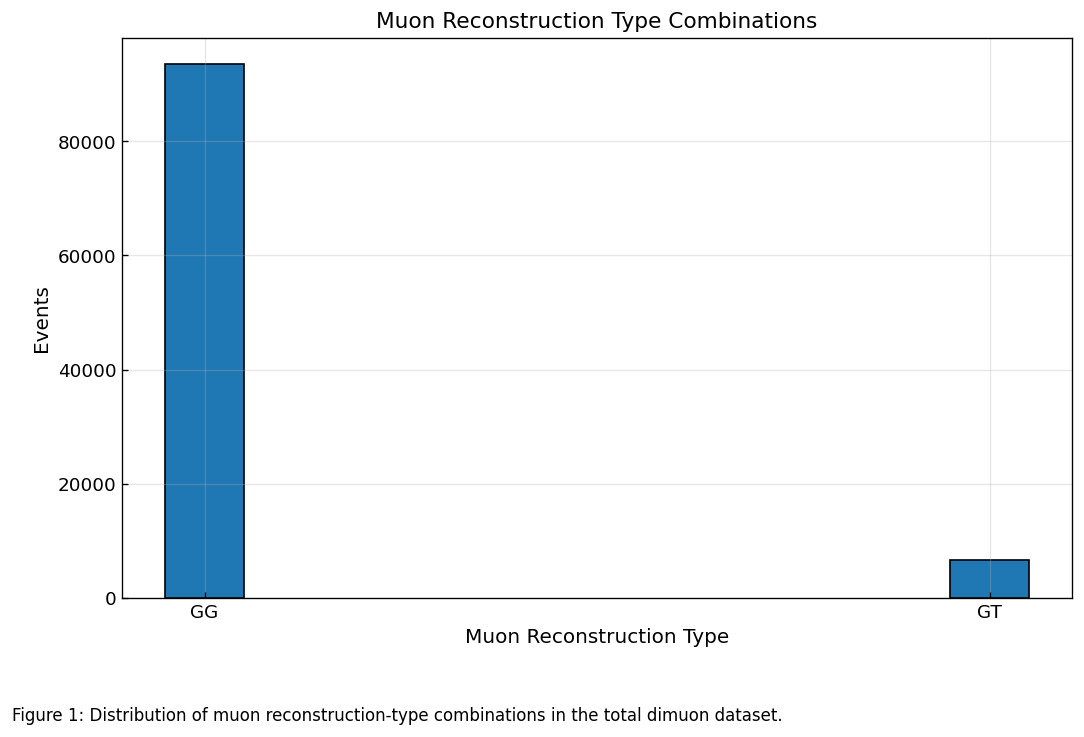

Quantity,Value
Initial Events,100000
Events after Global Muon Selection,93474
Selection Efficiency (relative to total dataset),93.47%


In [3]:
type_combinations = (
    dimuon["type1"] + dimuon["type2"]
).value_counts().sort_index()

display(type_combinations)

print("\n")  # Blank line spaces

plot_bar(
    type_combinations.index,
    type_combinations.values,
    width=0.1,
    xlabel="Muon Reconstruction Type",
    ylabel="Events",
    title="Muon Reconstruction Type Combinations",
    caption="Figure 1: Distribution of muon reconstruction-type combinations in the total dimuon dataset."
)


print("\n")  # Blank line spaces

# Select global muon pairs

dimuon_global_muon = select_global_muons(dimuon)

global_muon_selection_summary = (
    pd.DataFrame({
        "Quantity": [
            "Initial Events",
            "Events after Global Muon Selection",
            "Selection Efficiency (relative to total dataset)"
        ],
        "Value": [
            len(dimuon),
            len(dimuon_global_muon),
            f"{100*len(dimuon_global_muon)/len(dimuon):.2f}%"
        ]
    })
    .style
    .hide(axis="index")
    .set_caption("<b>Table 1:</b> Global Muon Selection Summary")
    .set_table_styles(TABLE_STYLES)
)

display(global_muon_selection_summary)

The distribution of reconstruction-type combinations demonstrates that the overwhelming majority of dimuon events consist of two Global Muons, accounting for approximately $93.5\%$ of the entire dataset. Events containing one or more Tracker Muons constitute only a small fraction of the available statistics. Applying the requirement that both reconstructed particles are identified as Global Muons therefore removes relatively few events while ensuring that the subsequent analysis is performed using the highest-quality reconstructed tracks. The resulting sample contains 93,474 events, corresponding to a selection efficiency of approximately $93.5\%$. There are no pairs comprising two Tracker Muons.

### 3.2 &nbsp; Opposite Charge Selection

The neutral Z-boson decays into a pair of oppositely charged leptons. Consequently, genuine $Z \rightarrow \mu^+\mu^-$ events are expected to contain one positively charged muon and one negatively charged muon. Requiring the reconstructed muons to possess opposite electric charge therefore provides a simple but effective method of suppressing background events arising from charge misidentification or unrelated muon pairs while preserving the characteristic topology of the signal process.

The selection criterion is implemented by requiring the product of the two reconstructed charges to satisfy:
$$ Q_1 Q_2 = -1 \:, \tag{1} $$
where $Q_1$ and $Q_2$ denote the electric charges of the first and second reconstructed muons, respectively. Since each muon carries a charge of either $+1$ or $−1$, only oppositely charged pairs satisfy this condition. Events failing this requirement are excluded from the subsequent analysis.

In [4]:
dimuon_charge = select_opposite_charge_pairs(dimuon_global_muon)

display(
    selection_summary(
        dimuon_global_muon,
        dimuon_charge,
        "Global Muon Selection",
        "Opposite Charge Selection",
        "<b>Table 2:</b> Muon Opposite Charge-Pair Selection Summary"
    )
)

Quantity,Value
Total Events,100000
Events after Global Muon Selection,93474
Events after Opposite Charge Selection,93474
Events Discarded by Opposite Charge Selection,0
Selection Efficiency (relative to previous selection),100.00%
Cumulative Efficiency (relative to total dataset),93.47%


Application of the opposite-charge selection criterion does not remove any events from the dataset, with all 93,474 Global Muon pairs satisfying the requirement in equation (1). This indicates that the sample has already been pre-selected to contain oppositely charged dimuon candidates. Although the selection has no practical effect on the event count, it remains an important validation step, confirming that every reconstructed dimuon candidate possesses the charge configuration expected for the decay $Z \rightarrow \mu^+\mu^-$. Retaining this criterion also ensures that the event-selection procedure remains physically motivated and readily applicable to more general datasets in which same-sign dimuon events may be present.

### 3.3 &nbsp; Transverse Momentum Requirement

Muons produced in the decay of the Z-boson are expected to possess relatively large transverse momenta owing to the substantial mass of the parent particle. In contrast, many background processes produce lower-energy muons, making the transverse momentum an effective discriminator between signal and background. A minimum transverse momentum threshold is therefore applied to both reconstructed muons in order to suppress low-energy dimuon events while retaining the majority of genuine $Z \rightarrow \mu^+\mu^-$ candidates.

As demonstrated in Notebook 5, a small number of events within the educational dataset contain transverse momentum values that are inconsistent with the corresponding Cartesian momentum components. Consequently, the selection criterion is applied using the independently reconstructed transverse momentum, $p_T = \sqrt{p_x^2 + p_y^2}\,$, rather than the values supplied directly in the dataset. This ensures that the event-selection procedure remains internally consistent and is unaffected by the isolated inconsistencies identified during the validation stage.

The reconstructed muons are first ordered according to their transverse momentum, defining the leading and subleading muons. A common transverse momentum threshold of $20 \, \text{GeV}$ [3] is then applied to both particles. Although many experimental analyses employ different requirements for the leading and subleading muons to satisfy specific trigger conditions, a symmetric threshold is adopted here to provide a simple and transparent selection while remaining consistent with commonly used criteria for $Z$-boson studies.

Quantity,Value
Total Events,100000
Events after Opposite Charge Selection,93474
Events after Transverse Momentum ($p_T$) Selection,5758
Events Discarded by Transverse Momentum ($p_T$) Selection,87716
Selection Efficiency (relative to previous selection),6.16%
Cumulative Efficiency (relative to total dataset),5.76%


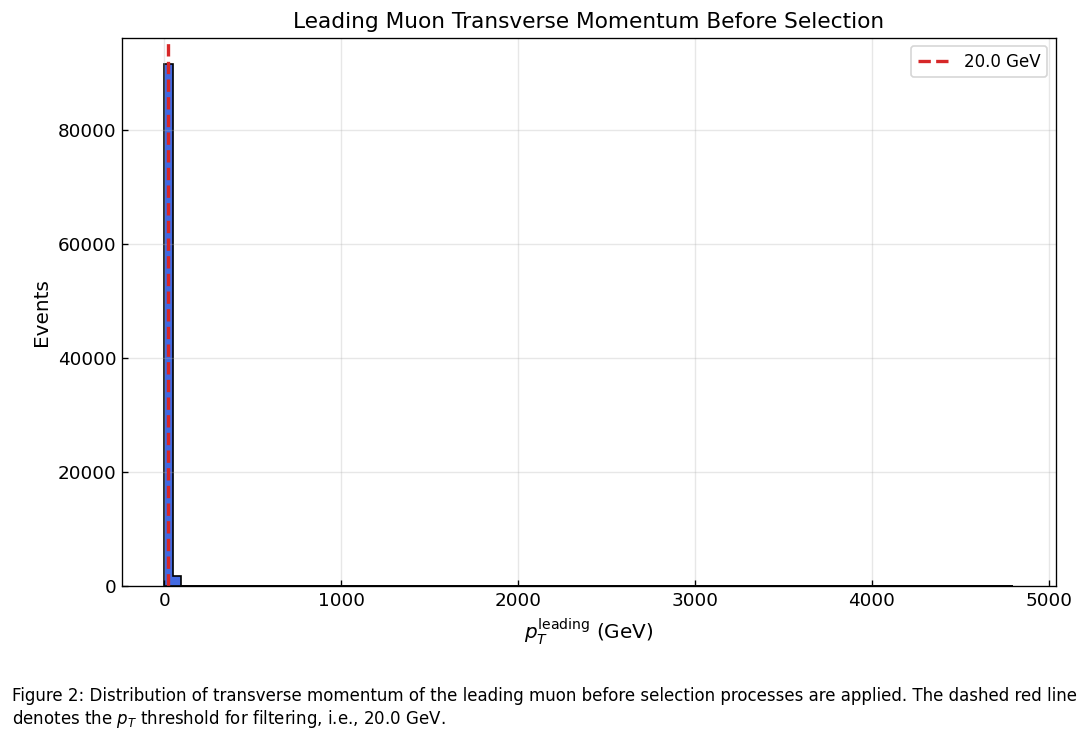

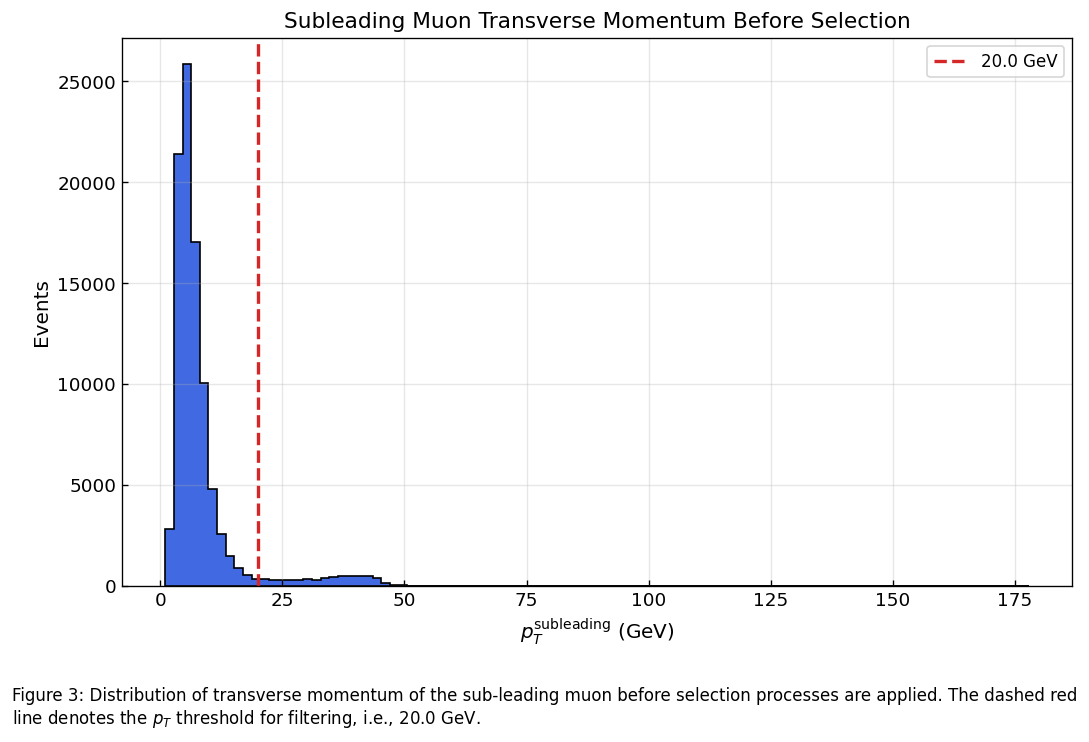

In [5]:
PT_THRESHOLD = 20.0   # GeV

leading_pt, subleading_pt = leading_subleading_pt(dimuon_charge)

plot_histogram(
    leading_pt,
    bins=100,
    xlabel=r"$p_T^{\text{leading}}$ (GeV)",
    ylabel="Events",
    title="Leading Muon Transverse Momentum Before Selection",
    vlines=[(PT_THRESHOLD, f"{PT_THRESHOLD} GeV", "#d62728")],
    caption=f"Figure 2: Distribution of transverse momentum of the leading muon before selection processes are applied. The dashed red line denotes the $p_T$ threshold for filtering, i.e., {PT_THRESHOLD} GeV.",
    save_path="../../figures/z_mumu_leading_muon_pt_selection_part_2.png",
    alt_caption=f"Distribution of transverse momentum of the leading muon before selection processes are applied. The dashed red line denotes the $p_T$ threshold for filtering, i.e., {PT_THRESHOLD} GeV."
)

print() # Blank line for spacing

plot_histogram(
    subleading_pt,
    bins=100,
    xlabel=r"$p_T^{\text{subleading}}$ (GeV)",
    ylabel="Events",
    title="Subleading Muon Transverse Momentum Before Selection",
    vlines=[(PT_THRESHOLD, f"{PT_THRESHOLD} GeV", "#d62728")],
    caption=f"Figure 3: Distribution of transverse momentum of the sub-leading muon before selection processes are applied. The dashed red line denotes the $p_T$ threshold for filtering, i.e., {PT_THRESHOLD} GeV.",
    save_path="../../figures/z_mumu_subleading_muon_pt_selection_part_2.png",
    alt_caption=f"Distribution of transverse momentum of the sub-leading muon before selection processes are applied. The dashed red line denotes the $p_T$ threshold for filtering, i.e., {PT_THRESHOLD} GeV."
)

print("\n")  # Blank line spaces

# Selection of transverse momentum of the muons

dimuon_pt = select_transverse_momentum(dimuon_charge, leading_threshold=PT_THRESHOLD, subleading_threshold=PT_THRESHOLD)

display(
    selection_summary(
        dimuon_charge,
        dimuon_pt,
        "Opposite Charge Selection",
        r"Transverse Momentum ($p_T$) Selection",
        "<b>Table 3:</b> Transverse Momentum Selection Summary"
    )
)

Application of the transverse momentum selection produced the largest reduction in event count observed during the entire event-selection procedure. Following the Global Muon and opposite-charge selections, 93,474 dimuon candidate events remained. Requiring both the leading and subleading reconstructed muons to possess transverse momenta exceeding $20\,\text{GeV}$ reduces this sample to 5,758 events, corresponding to a selection efficiency of $6.16\%$ relative to the previous stage.

This substantial reduction is expected from the underlying physics of proton-proton collisions at the LHC. The inclusive dimuon dataset contains a large population of low-energy muon pairs originating from processes such as low-mass Drell-Yan production [1], heavy-flavour hadron decays, and other Standard Model backgrounds. These processes predominantly produce muons with relatively small transverse momenta and therefore fail the imposed selection criterion.

In contrast, the decay products of the $Z$-boson are typically considerably more energetic owing to the boson's large mass of approximately $91.2\,\text{GeV}$ [2]. Consequently, the transverse momentum requirement preferentially retains events consistent with genuine $Z \rightarrow \mu^+\mu^-$ production while removing the majority of lower-energy background events. The pronounced decrease in event count therefore represents a desirable outcome, indicating that the selected sample has been significantly enriched in potential $Z$-boson candidates before the invariant mass reconstruction is performed.

### 3.4 &nbsp; Detector Acceptance: Pseudorapidity

The acceptance of the CMS detector is limited by its geometric coverage and reconstruction capabilities. Reliable muon reconstruction is achieved within the pseudorapidity range $|\eta| < 2.4$, which corresponds to the angular coverage of the CMS muon system. Particles produced outside this region either traverse insufficient detector material for accurate reconstruction or fall beyond the instrumented acceptance altogether.

Although the educational <code>Dimuon_DoubleMu</code> dataset is expected to have undergone preliminary reconstruction and quality selections before release, the detector acceptance criterion is nevertheless verified explicitly. Requiring both reconstructed muons to satisfy the pseudorapidity requirement ensures that all events retained for the subsequent analysis lie within the fiducial volume of the detector and remain consistent with the acceptance assumed in experimental measurements.

In [6]:
ETA_LIMIT = 2.4

dimuon_eta = select_pseudorapidity(dimuon_pt, eta_threshold=ETA_LIMIT)

display(
    selection_summary(
        dimuon_pt,
        dimuon_eta,
        r"Transverse Momentum ($p_T$) Selection",
        r"Pseudorapidity ($\eta$) Selection",
        "<b>Table 4:</b> Pseudorapidity Selection Summary"
    )
)

Quantity,Value
Total Events,100000
Events after Transverse Momentum ($p_T$) Selection,5758
Events after Pseudorapidity ($\eta$) Selection,5758
Events Discarded by Pseudorapidity ($\eta$) Selection,0
Selection Efficiency (relative to previous selection),100.00%
Cumulative Efficiency (relative to total dataset),5.76%


Application of the detector acceptance criterion produced little or no reduction in the event count, with nearly all reconstructed dimuon candidates already satisfying the requirement $|\eta| < 2.4$ for both muons. This behaviour is expected, as the educational CMS Open Data sample has been produced from particles successfully reconstructed by the CMS detector, whose muon system is itself limited to approximately this pseudorapidity range.

The detector acceptance selection therefore serves primarily as a validation step rather than a strong background rejection criterion. By explicitly verifying that all retained events lie within the fiducial acceptance of the detector, the analysis remains consistent with the geometric assumptions underlying the reconstruction process and ensures that subsequent measurements are performed using events for which the detector response is well understood.

### 3.5 &nbsp; Dimuon Mass Preselection

Following the reconstruction-quality and kinematic selections, a preliminary invariant mass requirement is applied in order to further suppress background events unrelated to $Z$-boson production. Unlike the previous selection criteria, this requirement makes use of the invariant mass variable $M$ supplied directly within the CMS educational dataset.

It is important to emphasise that this quantity is not used as the final measurement of the $Z$-boson mass. Instead, it serves solely as a preselection variable to isolate events lying within the expected mass region of the $Z$-boson resonance before the independent reconstruction is performed. The complete invariant mass reconstruction, based exclusively on the measured four-momentum components of the two muons, is carried out in the subsequent notebook.

Events are therefore retained only if the supplied invariant mass satisfies [4]:

$$60\,\text{GeV} < M < 120\,\text{GeV} \:, \tag{2} $$

corresponding to a symmetric mass window centred on the accepted $Z$-boson mass of approximately $91.2 \, \text{GeV}$ [2]. This requirement substantially reduces the remaining continuum background while preserving the overwhelming majority of genuine $Z \rightarrow \mu^+\mu^-$ candidate events.

Quantity,Value
Total Events,100000
Events after Pseudorapidity ($\eta$) Selection,5758
Events after Invariant Mass ($M$) Pre-Selection,5233
Events Discarded by Invariant Mass ($M$) Pre-Selection,525
Selection Efficiency (relative to previous selection),90.88%
Cumulative Efficiency (relative to total dataset),5.23%


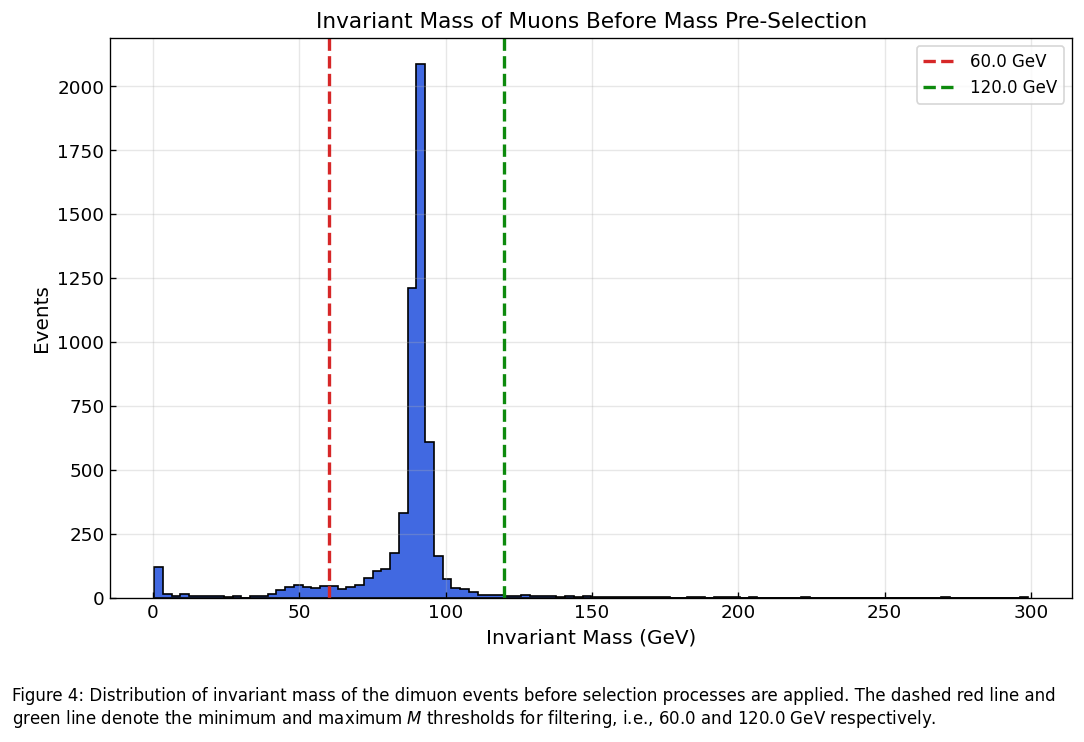

In [7]:
MASS_LIMITS = (60.0, 120.0)  # GeV

plot_histogram(
    dimuon_eta["M"],
    bins=100,
    xlabel="Invariant Mass (GeV)",
    ylabel="Events",
    title="Invariant Mass of Muons Before Mass Pre-Selection",
    vlines=[
        (MASS_LIMITS[0], f"{MASS_LIMITS[0]} GeV", "#d62728"),
        (MASS_LIMITS[1], f"{MASS_LIMITS[1]} GeV", "#0d8a0d")
    ],
    caption=("Figure 4: Distribution of invariant mass of the dimuon events before selection processes are applied. " +
    f"The dashed red line and green line denote the minimum and maximum $M$ thresholds for filtering, i.e., {MASS_LIMITS[0]} and {MASS_LIMITS[1]} GeV respectively."
    ),
    save_path="../../figures/z_mumu_inv_mass_selection_part_2.png",
    alt_caption=("Distribution of invariant mass of the dimuon events before selection processes are applied. " +
    f"The dashed red line and green line denote the minimum and maximum $M$ thresholds for filtering, i.e., {MASS_LIMITS[0]} and {MASS_LIMITS[1]} GeV respectively."
    )
)

print("\n")  # Blank line spaces

# Selection of invariant mass of the muons

dimuon_inv_mass = select_invariant_mass(dimuon_eta, mass_range=MASS_LIMITS)

display(
    selection_summary(
        dimuon_eta,
        dimuon_inv_mass,
        r"Pseudorapidity ($\eta$) Selection",
        r"Invariant Mass ($M$) Pre-Selection",
        "<b>Table 5:</b> Invariant Mass Pre-Selection Summary"
    )
)

Application of the invariant mass preselection produces a comparatively modest reduction in the event count relative to the preceding transverse momentum selection. Of the 5,758 events remaining after the pseudorapidity selection, 5,233 satisfy the requirement that the supplied dimuon invariant mass lies within the range $60–120\,\text{GeV}$. Consequently, only 525 events are rejected at this stage, corresponding to a selection efficiency of 90.88% relative to the previous selection and a cumulative efficiency of 5.23% with respect to the original dataset.

The relatively high selection efficiency demonstrates that the preceding reconstruction-quality and kinematic selections have already isolated a sample strongly enriched in potential $Z \rightarrow \mu^+\mu^-$ events. The chosen mass window encompasses the full $Z$-boson resonance while excluding a significant fraction of the remaining continuum background outside the signal region. As a result, the surviving event sample consists predominantly of dimuon candidates whose kinematic properties are consistent with the production and decay of an on-shell $Z$-boson.

It is important to emphasise that this selection does not constitute the final measurement of the $Z$-boson mass. The invariant mass values supplied within the dataset are employed solely as a preselection variable to obtain a high-purity event sample. In the following notebook, the invariant mass will be reconstructed independently from the measured four-momentum components of the two muons, allowing the $Z$-boson resonance to be reproduced without relying on the dataset's precomputed mass variable.

### 3.6 &nbsp; Selection Summary

Selection Step,Events Remaining,Cumulative Efficiency
Initial Dataset,"100,000",100.0%
Global Muon Quality Cuts,"93,474",93.5%
Opposite Charge Requirement,"93,474",93.5%
$p_T$ Threshold,"5,758",5.8%
Pseudorapidity ($\eta$) Cut,"5,758",5.8%
Invariant Mass Window,"5,233",5.2%


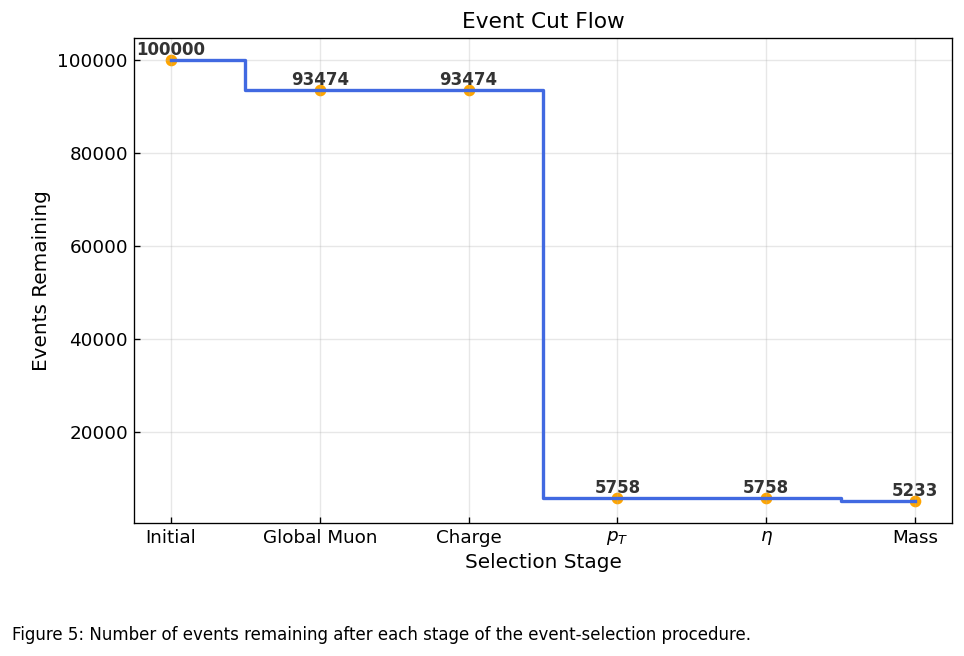

Figure saved at: figures/../../figures/z_mumu_selection_event_cut_flowchart_part_2.png


In [8]:
# Event label and count at each step
selection_labels = [
    "Initial",
    "Global Muon",
    "Charge",
    r"$p_T$",
    r"$\eta$",
    "Mass"
]

selection_counts = [
    len(dimuon),
    len(dimuon_global_muon),
    len(dimuon_charge),
    len(dimuon_pt),
    len(dimuon_eta),
    len(dimuon_inv_mass)
]

# Summary table dataframe

cut_flow_statistics = (
    pd.DataFrame({
        "Selection Step": [
            "Initial Dataset",
            "Global Muon Quality Cuts",
            "Opposite Charge Requirement",
            r"$p_T$ Threshold",
            r"Pseudorapidity ($\eta$) Cut",
            "Invariant Mass Window"
        ],
        "Events Remaining": selection_counts,
        "Cumulative Efficiency": [
            f"{100 * selection_counts[0] / selection_counts[0]:.1f}%",
            f"{100 * selection_counts[1] / selection_counts[0]:.1f}%",
            f"{100 * selection_counts[2] / selection_counts[0]:.1f}%",
            f"{100 * selection_counts[3] / selection_counts[0]:.1f}%",
            f"{100 * selection_counts[4] / selection_counts[0]:.1f}%",
            f"{100 * selection_counts[5] / selection_counts[0]:.1f}%"
        ]
    })
)

cut_flow_summary = (
    cut_flow_statistics
        .style
        .hide(axis="index")
        .format({"Events Remaining": "{:,}"}) 
        .set_caption("<b>Table 6:</b> Complete Event Selection Cut Flow Summary")
        .set_table_styles(TABLE_STYLES) 
)

display(cut_flow_summary)

print("\n")  # Blank line spaces

plot_line(
    selection_labels,
    selection_counts,
    caption="Figure 5: Number of events remaining after each stage of the event-selection procedure.",
    save_path="../../figures/z_mumu_selection_event_cut_flowchart_part_2.png",
    alt_caption="Number of events remaining after each stage of the event-selection procedure applied in notebook 6."
)

The largest reduction in event count arises from the transverse momentum requirement, reflecting the substantial population of low-energy dimuon events present within the inclusive sample. Subsequent selections remove progressively smaller fractions of the data while preferentially retaining the kinematic characteristics expected for $Z$-boson decays. Some selections, such as the opposite charge requirement and pseudorapidity selection do not affect the count of events, since the dataset provided already passed these criteria, as described section 2.3 in the previous notebook.

## 4. &nbsp; Final Dataset

### 4.1 &nbsp; Dataset Descriptions

In [9]:
# Final dataset after all the filters

dimuon_selected = dimuon_inv_mass.copy()

display(dataset_information(dimuon_selected)
    .style.set_caption("<b>Table 7:</b> Data Types of the Filtered dataset.")
    .set_table_styles(TABLE_STYLES)
)

print("\n")  # Blank line spaces

display(dimuon_selected.head()
    .rename(index=lambda x: x + 1)
    .style.set_caption("<b>Table 8:</b> First five events of the filtered dimuon dataset. The first column from the left represents the index values from the total dataset.")
    .set_table_styles(TABLE_STYLES)
)

,Data Type,Non-Null Entries
Run,int64,5233
Event,int64,5233
type1,str,5233
E1,float64,5233
px1,float64,5233
py1,float64,5233
pz1,float64,5233
pt1,float64,5233
eta1,float64,5233
phi1,float64,5233


,Run,Event,type1,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
22,165617,74969122,G,59.922600,-46.151600,29.411500,-24.407000,54.726600,-0.432400,2.574200,1,G,52.446500,30.109700,-16.398900,-39.687600,34.285900,-0.988500,-0.498700,-1,89.955700
37,165617,75138253,G,97.101100,-23.614400,6.666000,-93.949700,24.537200,-2.052400,2.866500,-1,G,30.599200,-11.613400,-25.984800,11.234700,28.461900,0.385100,-1.991100,1,88.608100
47,165617,75887636,G,152.972000,7.465700,-30.709800,-149.671000,31.604200,-2.259300,-1.332300,-1,G,33.583500,-9.287800,28.745700,-14.671900,30.208900,-0.468400,1.883300,1,88.243800
79,165617,75833588,G,181.877000,44.142700,-14.949800,175.804000,46.605500,2.037900,-0.326500,1,G,170.021000,-34.630100,12.324800,166.000000,36.757900,2.212800,2.799700,-1,83.094300
111,165617,75779415,G,50.244000,37.807200,-12.204400,-30.759000,39.728300,-0.712400,-0.312200,1,G,49.239600,-47.606400,8.233800,-9.506100,48.313200,-0.195500,2.970300,-1,90.354400


Following the sequential application of the selection criteria, the remaining dataset consists predominantly of high-quality opposite-sign dimuon candidates possessing kinematic properties consistent with the expected decay products of the $Z$-boson. This filtered sample provides the basis for the invariant-mass reconstruction performed in the subsequent notebook.

### 4.2 &nbsp; Dataset Export

In [10]:
dimuon_selected.to_csv(
    "../../data/processed/z_dimuon_part_2_selected.csv",
    index=False
)  # Save as csv file for future use.

cut_flow_statistics.to_csv("../../data/processed/z_dimuon_part_2_selection_summary.csv", index=False)  # Save the step-by-step cut flow statistics

print("Filtered dataset saved.")

Filtered dataset saved.


## 5. &nbsp; Conclusion

A sequence of physics-motivated event-selection criteria has been applied to the inclusive CMS Dimuon_DoubleMu dataset in order to isolate a high-purity sample of $Z \rightarrow \mu^+\mu^-$ candidate events suitable for invariant mass reconstruction. The selection procedure began by retaining only events containing two Global Muons, thereby ensuring that the analysis utilised the highest-quality reconstructed tracks available. Verification of the opposite-charge requirement confirmed that all selected dimuon pairs already satisfied the expected charge configuration for neutral $Z$-boson decays.

The most significant reduction in the event sample resulted from the transverse momentum selection. By reconstructing the transverse momentum independently from the Cartesian momentum components and requiring both the leading and subleading muons to satisfy a threshold of $20\,\text{GeV}$ [3], the analysis removed the large population of low-energy dimuon events originating from background processes while preferentially retaining candidates consistent with the decay of a high-mass $Z$-boson. The pseudorapidity selection subsequently confirmed that the surviving events lay within the fiducial acceptance of the CMS muon detector, producing virtually no further reduction in the event count, as expected for a reconstructed CMS dataset.

Finally, a broad invariant mass preselection of $60–120\,\text{GeV}$ [4] was applied using the invariant mass values supplied within the educational dataset. This requirement was employed solely to suppress the remaining continuum background and obtain a cleaner sample of $Z$-boson candidates; it does not constitute the final measurement of the $Z$-boson mass. The complete invariant mass reconstruction will instead be performed independently in the following notebook using the measured four-momentum components of the reconstructed muons.

Following the complete event-selection procedure, 5,233 events remain from the original sample of 100,000, corresponding to a cumulative selection efficiency of $5.23\%$. Although only a small fraction of the original dataset is retained, the resulting sample is expected to be highly enriched in genuine $Z \rightarrow \mu^+\mu^-$ events, providing a robust foundation for the independent reconstruction and analysis of the $Z$-boson invariant mass presented in the next stage of this project.

## References

[1] <https://cds.cern.ch/record/375809/files/ep-98-190.pdf>.  _$\,\text{J}/\psi$, $\psi'$ and Drell-Yan production in S-U interactions at 200 GeV per nucleon_¸ European Laboratory for Particle Physics. CERN–EP / 98–190. 11 December 1998. Date accessed 05/08/2026.<br>
[2] <https://pdg.lbl.gov/2026/listings/rpp2026-list-z-boson.pdf>. Takahashi, F. _et al_. Particle Data Group. Int. J. Mod. Phys. A 41, 2630011. 2026. Date accessed 05/08/2026.<br>
[3] <https://doi.org/10.1016/j.physletb.2018.12.073>. _Measurements of properties of the Higgs boson decaying to a W boson pair in pp collisions at $\sqrt{s} = 13\,\text{TeV}$_. The CMS Collaboration. Physics Letters B, Vol. 791. pages 96-129. 2019. Date accessed 05/08/2026.<br>
[4] <https://cms-results.web.cern.ch/cms-results/public-results/publications/SMP-20-004/index.html>. Measurement of the inclusive cross sections for W and Z boson production in proton-proton collisions at $\sqrt{s} = 5.02$ and $13\,\text{TeV}$. CMS Collaboration. JHEP 04 (2025) 162. 7 August 2024. Date accessed 06/08/2026.